In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("wc_2026.csv")
print(df.head())

df["date"] = pd.to_datetime(df["date"])
df.info()

df.isnull().sum()

fifa_rank = df[["team1_fifa_rank","team2_fifa_rank"]]

  group        stage        team1         team2           venue         city  \
0     A  Group Stage       Mexico  South Africa  Estadio Azteca  Mexico City   
1     A  Group Stage  South Korea       Czechia   Estadio Akron  Guadalajara   
2     A  Group Stage  South Korea        Mexico   Estadio Akron  Guadalajara   
3     A  Group Stage      Czechia  South Africa   Estadio Akron  Guadalajara   
4     A  Group Stage      Czechia        Mexico  Estadio Azteca  Mexico City   

  country        date kickoff_et team1_confederation  team1_fifa_rank  \
0  Mexico  2026-06-11   20:00 ET            CONCACAF             15.0   
1  Mexico  2026-06-11   22:00 ET                 AFC             25.0   
2  Mexico  2026-06-18   21:00 ET                 AFC             25.0   
3  Mexico  2026-06-18   18:00 ET                UEFA             41.0   
4  Mexico  2026-06-24   21:00 ET                UEFA             41.0   

      team1_coach team2_confederation  team2_fifa_rank     team2_coach  
0  Javi

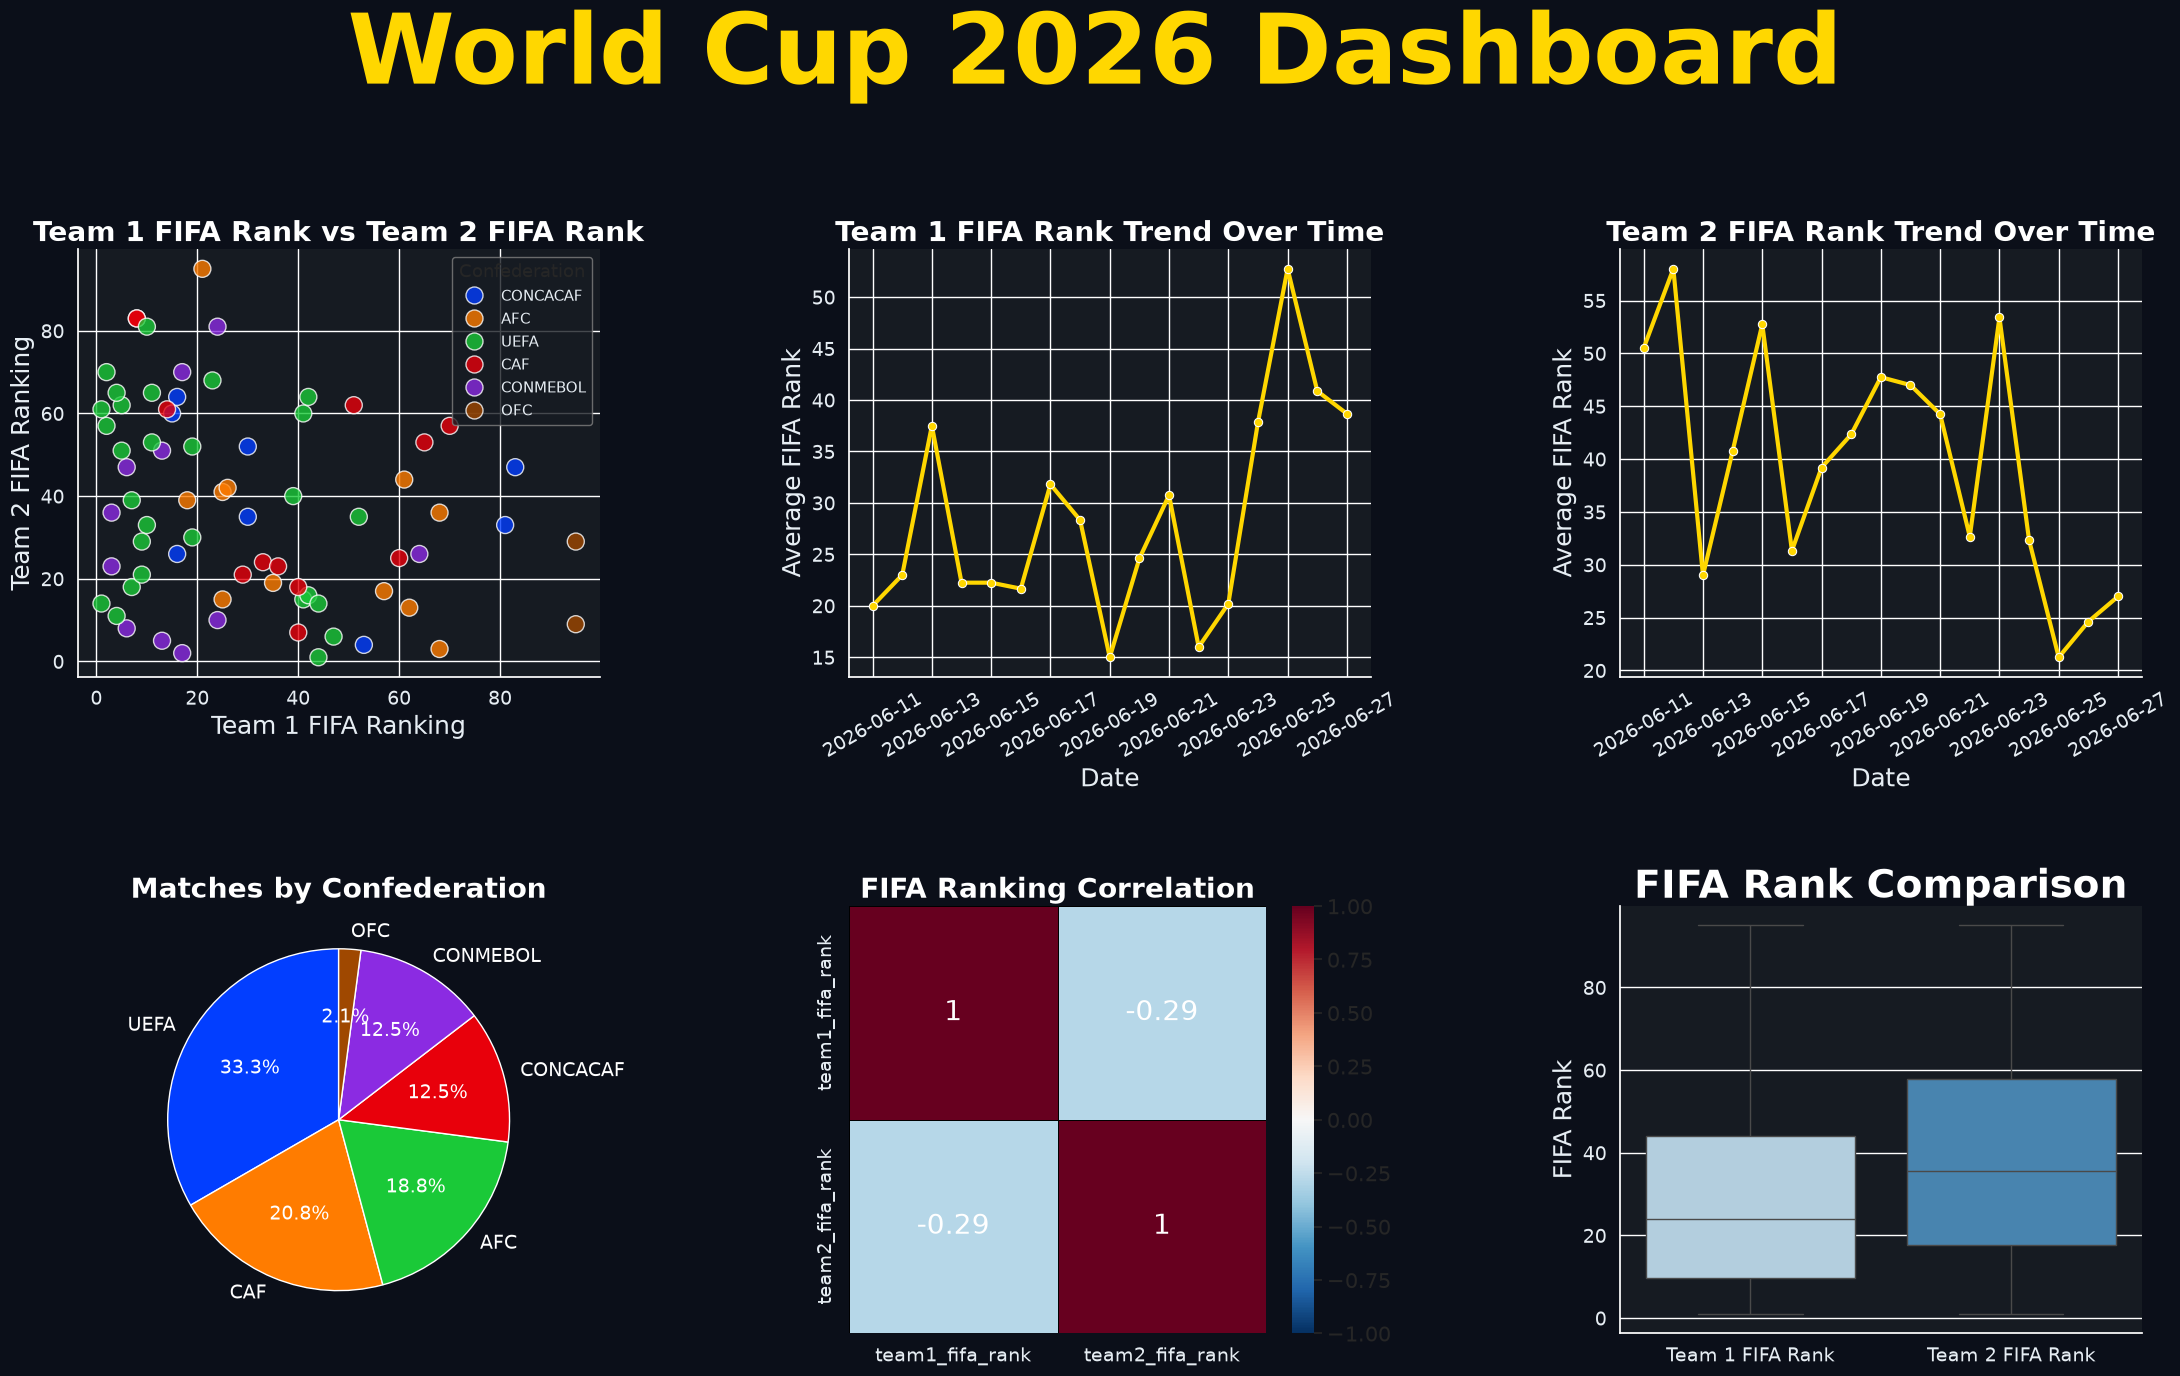

In [5]:
fig, ax = plt.subplots(2,3,figsize=(25,15)) # rows, columns & mini boxes OK

plt.tight_layout(pad=8) # gap between rows OK

fig.patch.set_facecolor("#0B0F19") # whole dashboard background "#FAF6F6E4"

for a in ax.flat: # color for mini boxes
    a.set_facecolor("#161B22")

sns.set_theme(style= 'darkgrid', palette= 'bright', font= 'DejaVu Sans',font_scale= 1.4) # design inside mini boxes

plt.suptitle("World Cup 2026 Dashboard", fontsize = 70,fontweight = 'bold', y = 1.03, color = "#FFD700", fontfamily = "DejaVu Sans") # header

for a in ax.flat:
    a.tick_params(colors="#E6EDF3", labelsize = 14)
    a.xaxis.label.set_color("#E6EDF3") # axis label colour
    a.yaxis.label.set_color("#E6EDF3") # axis label colour
    a.xaxis.label.set_size(18)  # axis label size
    a.yaxis.label.set_size(18)  # axis label size
    a.spines["top"].set_visible(False) # remove top/right border
    a.spines["right"].set_visible(False) # remove top/right border

conf_palette = {"UEFA": "#1E88E5","CONMEBOL": "#43A047","AFC": "#FB8C00","CAF": "#E53935","CONCACAF": "#8E24AA","OFC": "#757575"}
sns.scatterplot(data=df,x="team1_fifa_rank",y="team2_fifa_rank",color="#00E5FF",ax=ax[0,0],s=150,hue="team1_confederation", alpha = 0.8)
ax[0,0].legend(title="Confederation",fontsize=11,title_fontsize=13,frameon=True,facecolor="#161B22",edgecolor="grey",labelcolor="#E6EDF3")
ax[0,0].set_title("Team 1 FIFA Rank vs Team 2 FIFA Rank", color = "#FFFFFF", fontsize =20, fontweight ="bold") # subplot title
ax[0,0].set_xlabel("Team 1 FIFA Ranking") # axis labels
ax[0,0].set_ylabel("Team 2 FIFA Ranking") # axis labels
ax[0,0].grid(True) 

rank_trend = (df.groupby("date")["team1_fifa_rank"].mean().reset_index())
sns.lineplot(data=rank_trend,x="date",y="team1_fifa_rank",marker="o",linewidth=3,color="#FFD700",ax=ax[0,1])
ax[0,1].set_title("Team 1 FIFA Rank Trend Over Time",fontsize=20,fontweight="bold",color="white")
ax[0,1].set_xlabel("Date")
ax[0,1].set_ylabel("Average FIFA Rank")
ax[0,1].tick_params(axis="x",rotation=30)

rank_trend = (df.groupby("date")["team2_fifa_rank"].mean().reset_index())
sns.lineplot(data=rank_trend,x="date",y="team2_fifa_rank",marker="o",linewidth=3,color="#FFD700",ax=ax[0,2])
ax[0,2].set_title("Team 2 FIFA Rank Trend Over Time",fontsize=20,fontweight="bold",color="white")
ax[0,2].set_xlabel("Date")
ax[0,2].set_ylabel("Average FIFA Rank")
ax[0,2].tick_params(axis="x",rotation=30)

confederation = pd.concat([df["team1_confederation"],df["team2_confederation"]])
conf_count = confederation.value_counts()
ax[1,0].pie(conf_count,labels=conf_count.index,autopct="%1.1f%%",startangle=90,textprops={"color":"white","fontsize":14})
ax[1,0].set_title("Matches by Confederation",fontsize=20,fontweight="bold",color="white")

corr_matrix = df[["team1_fifa_rank","team2_fifa_rank"]].corr()
sns.heatmap(corr_matrix,annot=True,cmap="RdBu_r",linewidths=0.5,linecolor="black",vmin=-1,vmax=1,annot_kws={"size":20,"color":"white"},ax=ax[1,1])
ax[1,1].set_title("FIFA Ranking Correlation",fontsize=20,fontweight="bold",color="white")

rank_compare = pd.DataFrame({"Team 1 FIFA Rank": df["team1_fifa_rank"],"Team 2 FIFA Rank": df["team2_fifa_rank"]})
sns.boxplot(data=rank_compare,palette="Blues",ax=ax[1,2])
ax[1,2].set_title("FIFA Rank Comparison",fontsize=28,fontweight="bold",color="white")
ax[1,2].set_ylabel("FIFA Rank")

plt.show()
